In [ ]:
!pip install gdown -q

FILE_ID = "1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS"
!gdown --id {FILE_ID} -O dataset.zip

!unzip -q dataset.zip -d /content/dataset
print("Done.")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS
From (redirected): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS&confirm=t&uuid=f331e15f-4a60-4b6b-a9b3-2913e3bca23c
To: /content/dataset.zip
100% 4.08G/4.08G [00:51<00:00, 79.7MB/s]
Done.


In [ ]:
import os

root = "/content/dataset"

def walk_summary(root, max_depth=3):
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        n_files = len(filenames)
        sample = filenames[:3]
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{n_files} files]  e.g. {sample}")

walk_summary(root)

# Also flag any CSV/label files anywhere in the tree
print("\n--- CSV/label files found ---")
for dirpath, _, filenames in os.walk(root):
    for f in filenames:
        if f.lower().endswith(('.csv', '.txt', '.json', '.xlsx')):
            print(os.path.join(dirpath, f))

dataset/  [2 files]  e.g. ['Tasks_and_Classes.md', 'metadata.csv']
  catalog/  [5 files]  e.g. ['split_distribution.png', 'catalog_summary.csv', 'source_distribution.png']
  splits/  [1 files]  e.g. ['val.csv']
  images/  [11839 files]  e.g. ['ORIGA_255.jpg', 'APTOS_image_02403.png', 'ODIR_1545_right.jpg']

--- CSV/label files found ---
/content/dataset/metadata.csv
/content/dataset/catalog/catalog_summary.csv
/content/dataset/splits/val.csv


In [ ]:
import pandas as pd

# 1. The class/task documentation — read this first, it likely defines the 8 classes exactly
with open("/content/dataset/Tasks_and_Classes.md") as f:
    print(f.read())

# Eye Disease Dataset: Available Tasks & Class Descriptions

This document outlines the computer vision and machine learning tasks that can be accomplished using the unified Eye Disease Dataset, along with a detailed medical description of the 8 disease classes present in the corpus.

---

## Part 1: Available Machine Learning Tasks

Given the scale (11,839 images), diversity (4 distinct data sources), and distribution of this dataset, you can perform several advanced machine learning tasks:

### 1. Multi-class Image Classification
The most direct application is training Convolutional Neural Networks (CNNs) like ResNet or DenseNet, or Vision Transformers (ViTs), to categorize a fundus image into one of the 8 discrete classes. This acts as a comprehensive diagnostic assistant.

### 2. Binary Screening (Disease vs. Normal)
You can subset the dataset to build highly specialized, high-accuracy binary classifiers. Examples include:
- **General Screening:** Normal vs. Abnormal (All other cla

In [ ]:
# 2. Main metadata (this almost certainly holds the image filename -> label mapping)
meta = pd.read_csv("/content/dataset/metadata.csv")
print(meta.shape)
print(meta.columns.tolist())
meta.head(10)

(11839, 4)
['filename', 'dataset', 'unified_label', 'original_label']


,filename,dataset,unified_label,original_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal
5,ACRIMA_Im006_ACRIMA.jpg,ACRIMA,Normal,Normal
6,ACRIMA_Im007_ACRIMA.jpg,ACRIMA,Normal,Normal
7,ACRIMA_Im008_ACRIMA.jpg,ACRIMA,Normal,Normal
8,ACRIMA_Im009_ACRIMA.jpg,ACRIMA,Normal,Normal
9,ACRIMA_Im010_ACRIMA.jpg,ACRIMA,Normal,Normal


In [ ]:
# 3. Check for multi-label vs single-label — critical for loss function choice
print(meta.isna().sum())
# if there's a single 'label' or 'class' column vs multiple binary columns (N, D, G, C, A, H, M, O)

filename          0
dataset           0
unified_label     0
original_label    0
dtype: int64


In [ ]:
# 4. Splits folder — only val.csv showed up, let's see what's really in there
import os
print(os.listdir("/content/dataset/splits"))
val = pd.read_csv("/content/dataset/splits/val.csv")
print(val.shape)
val.head()

['val.csv']
(1197, 4)


,filename,dataset,unified_label,original_label
0,ODIR_2634_left.jpg,ODIR5K,Normal,N
1,ODIR_982_right.jpg,ODIR5K,Others,O
2,APTOS_image_02639.png,APTOS2019,Diabetic Retinopathy,DR
3,ACRIMA_Im309_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ODIR_2644_right.jpg,ODIR5K,Normal,N


In [ ]:
# 5. Catalog folder summary CSV + README (likely explains the split methodology & class counts)
print(os.listdir("/content/dataset/catalog"))
with open("/content/dataset/catalog/README.md") as f:
    print(f.read())

['split_distribution.png', 'catalog_summary.csv', 'source_distribution.png', 'class_distribution.png', 'README.md']
# Unified Eye Disease Dataset

This unified dataset consists of **11839** fundus images across 8 disease classes, aggregated from 4 public datasets.

## Summary Statistics
| Class | Total Images | Train | Val | Test |
|---|---|---|---|---|
| Normal | 4698 | 3835 | 485 | 488 |
| Diabetic Retinopathy | 4113 | 3234 | 408 | 409 |
| Others | 1102 | 882 | 110 | 110 |
| Glaucoma | 930 | 744 | 93 | 93 |
| Cataract | 340 | 272 | 34 | 34 |
| Myopia | 294 | 235 | 30 | 29 |
| AMD | 274 | 219 | 28 | 27 |
| Hypertension | 88 | 70 | 9 | 9 |


## Source Datasets
- **ODIR5K**: 7000 images
- **APTOS2019**: 3484 images
- **ACRIMA**: 705 images
- **ORIGA**: 650 images



In [ ]:
cat_summary = pd.read_csv("/content/dataset/catalog/catalog_summary.csv")
cat_summary

,Class,Total Images,Train,Val,Test
0,Normal,4698,3835,485,488
1,Diabetic Retinopathy,4113,3234,408,409
2,Others,1102,882,110,110
3,Glaucoma,930,744,93,93
4,Cataract,340,272,34,34
5,Myopia,294,235,30,29
6,AMD,274,219,28,27
7,Hypertension,88,70,9,9


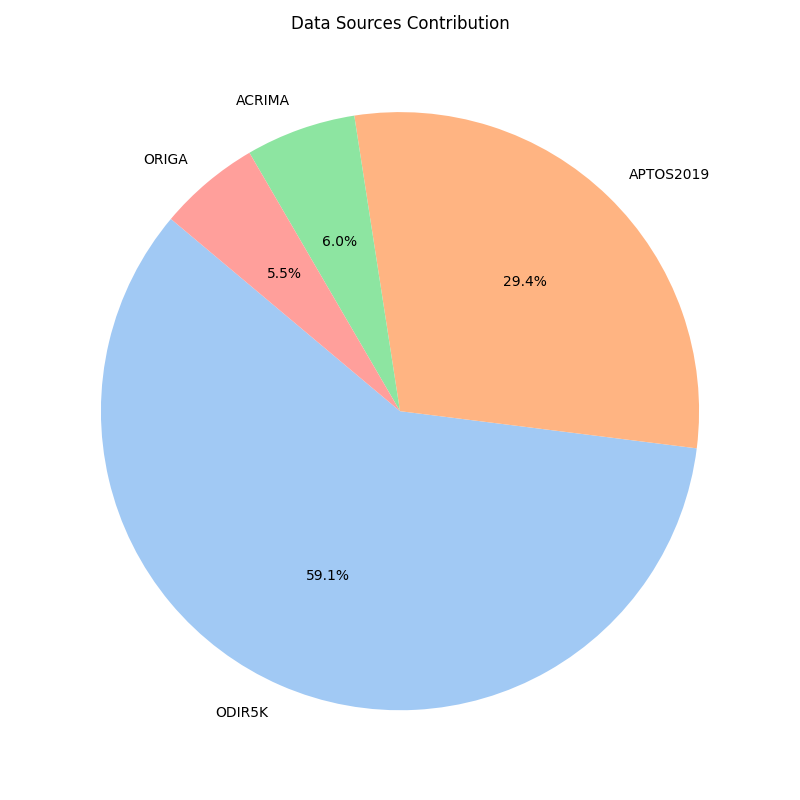

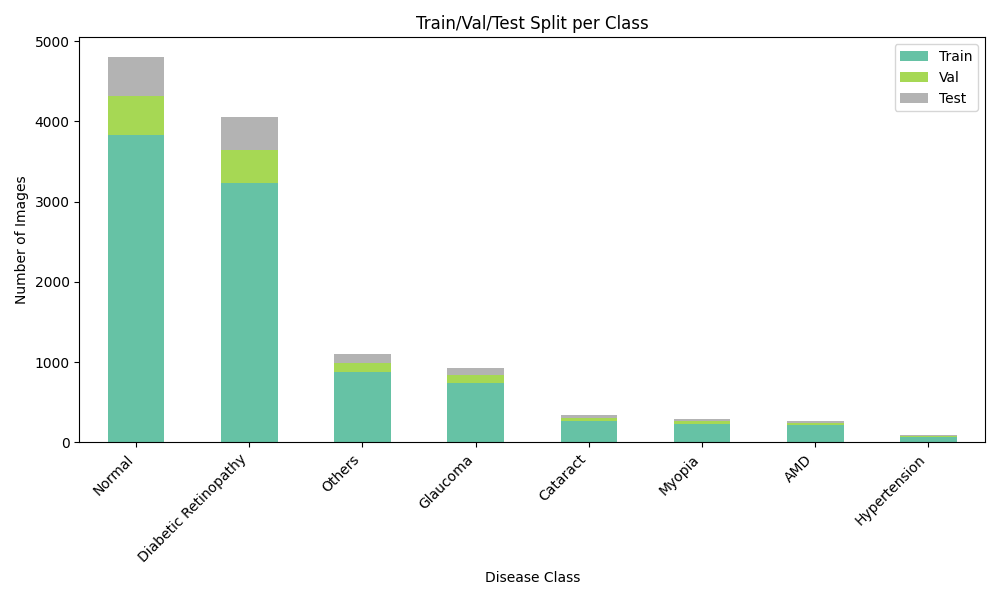

In [ ]:
# 6. View the pre-made distribution plots
from PIL import Image
display(Image.open("/content/dataset/catalog/source_distribution.png"))
display(Image.open("/content/dataset/catalog/split_distribution.png"))

In [ ]:
# 1. metadata.csv structure is label a single column or one-hot per disease?
meta = pd.read_csv("/content/dataset/metadata.csv")
print(meta.shape)
print(meta.columns.tolist())
meta.head(10)

(11839, 4)
['filename', 'dataset', 'unified_label', 'original_label']


,filename,dataset,unified_label,original_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal
5,ACRIMA_Im006_ACRIMA.jpg,ACRIMA,Normal,Normal
6,ACRIMA_Im007_ACRIMA.jpg,ACRIMA,Normal,Normal
7,ACRIMA_Im008_ACRIMA.jpg,ACRIMA,Normal,Normal
8,ACRIMA_Im009_ACRIMA.jpg,ACRIMA,Normal,Normal
9,ACRIMA_Im010_ACRIMA.jpg,ACRIMA,Normal,Normal


In [ ]:
# 2. splits folder  does it only have val.csv, or did train.csv/test.csv just not print earlier?
import os
print(os.listdir("/content/dataset/splits"))

In [ ]:
# 3. whatever's inside val.csv (or train/test if they exist) — same columns as metadata, or just filename+split?
val = pd.read_csv("/content/dataset/splits/val.csv")
print(val.columns.tolist())
val.head()

['filename', 'dataset', 'unified_label', 'original_label']


,filename,dataset,unified_label,original_label
0,ODIR_2634_left.jpg,ODIR5K,Normal,N
1,ODIR_982_right.jpg,ODIR5K,Others,O
2,APTOS_image_02639.png,APTOS2019,Diabetic Retinopathy,DR
3,ACRIMA_Im309_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ODIR_2644_right.jpg,ODIR5K,Normal,N


In [ ]:
import os
print(os.listdir("/content/dataset/splits"))

['val.csv']


In [ ]:
val = pd.read_csv("/content/dataset/splits/val.csv")
print(len(val))
print(val['filename'].isin(meta['filename']).all())  # should be True
print(val['unified_label'].value_counts())  # should roughly match README's Val column

1197
True
unified_label
Normal                  485
Diabetic Retinopathy    408
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   30
AMD                      28
Hypertension              9
Name: count, dtype: int64


EDA

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

meta = pd.read_csv("/content/dataset/metadata.csv")
val_df = pd.read_csv("/content/dataset/splits/val.csv")

# Remove val images from the pool -> remaining goes to train/test
remaining = meta[~meta['filename'].isin(val_df['filename'])].reset_index(drop=True)
print("Total:", len(meta), "| Val:", len(val_df), "| Remaining pool:", len(remaining))

train_df, test_df = train_test_split(
    remaining,
    test_size=0.1,
    stratify=remaining['unified_label'],
    random_state=42
)

train_df.to_csv("/content/dataset/splits/train.csv", index=False)
test_df.to_csv("/content/dataset/splits/test.csv", index=False)

print("Train:", len(train_df), "| Test:", len(test_df))
print("\nTrain distribution:\n", train_df['unified_label'].value_counts())
print("\nTest distribution:\n", test_df['unified_label'].value_counts())

Total: 11839 | Val: 1197 | Remaining pool: 10642
Train: 9577 | Test: 1065

Train distribution:
 unified_label
Normal                  3808
Diabetic Retinopathy    3318
Others                   893
Glaucoma                 753
Cataract                 275
Myopia                   238
AMD                      221
Hypertension              71
Name: count, dtype: int64

Test distribution:
 unified_label
Normal                  423
Diabetic Retinopathy    369
Others                   99
Glaucoma                 84
Cataract                 31
Myopia                   26
AMD                      25
Hypertension              8
Name: count, dtype: int64


In [ ]:
import pandas as pd

meta = pd.read_csv("/content/dataset/metadata.csv")
train_df = pd.read_csv("/content/dataset/splits/train.csv")
val_df   = pd.read_csv("/content/dataset/splits/val.csv")
test_df  = pd.read_csv("/content/dataset/splits/test.csv")

classes = meta['unified_label'].value_counts().index.tolist()

summary = pd.DataFrame({
    "Total": meta['unified_label'].value_counts(),
    "Train": train_df['unified_label'].value_counts(),
    "Val":   val_df['unified_label'].value_counts(),
    "Test":  test_df['unified_label'].value_counts(),
}).fillna(0).astype(int)

summary = summary.loc[classes]  # order by total descending
summary["Train %"] = (summary["Train"] / summary["Total"] * 100).round(1)
summary["Val %"]   = (summary["Val"]   / summary["Total"] * 100).round(1)
summary["Test %"]  = (summary["Test"]  / summary["Total"] * 100).round(1)

print(summary)
print("\nTotal images:", meta.shape[0])
print("Total classes:", meta['unified_label'].nunique())
print("Imbalance ratio (max/min):", summary["Total"].max() / summary["Total"].min())

                      Total  Train  Val  Test  Train %  Val %  Test %
unified_label                                                        
Normal                 4698   3808  485   423     81.1   10.3     9.0
Diabetic Retinopathy   4113   3318  408   369     80.7    9.9     9.0
Others                 1102    893  110    99     81.0   10.0     9.0
Glaucoma                930    753   93    84     81.0   10.0     9.0
Cataract                340    275   34    31     80.9   10.0     9.1
Myopia                  294    238   30    26     81.0   10.2     8.8
AMD                     274    221   28    25     80.7   10.2     9.1
Hypertension             88     71    9     8     80.7   10.2     9.1

Total images: 11839
Total classes: 8
Imbalance ratio (max/min): 53.38636363636363


## Eye Disease Classes Overview

| Class | Description | Key Fundus Signs |
|---|---|---|
| **Normal** | Healthy retina with no detectable pathology | Clear optic disc, normal vessel pattern, no lesions |
| **Diabetic Retinopathy (DR)** | Retinal damage caused by long-term diabetes affecting blood vessels | Microaneurysms, hemorrhages, exudates, neovascularization in advanced stages |
| **Glaucoma** | Progressive optic nerve damage, often linked to elevated eye pressure | Enlarged cup-to-disc ratio, optic disc pallor or notching |
| **Cataract** | Clouding of the eye's lens, not the retina itself | Hazy, blurred, low-contrast fundus image due to opacity in front of the retina |
| **AMD (Age-related Macular Degeneration)** | Degeneration of the macula, affecting central vision | Drusen deposits, pigmentary changes near the macula |
| **Hypertension** | Retinal damage from chronic high blood pressure | Arteriovenous nicking, flame-shaped hemorrhages, cotton wool spots |
| **Myopia** | Pathologic nearsightedness-related retinal and optic disc changes | Tilted/crescent-shaped optic disc, retinal thinning, tessellated fundus appearance |
| **Others** | Catch-all category for conditions outside the above 7 classes | Heterogeneous — mixed and varied presentations |

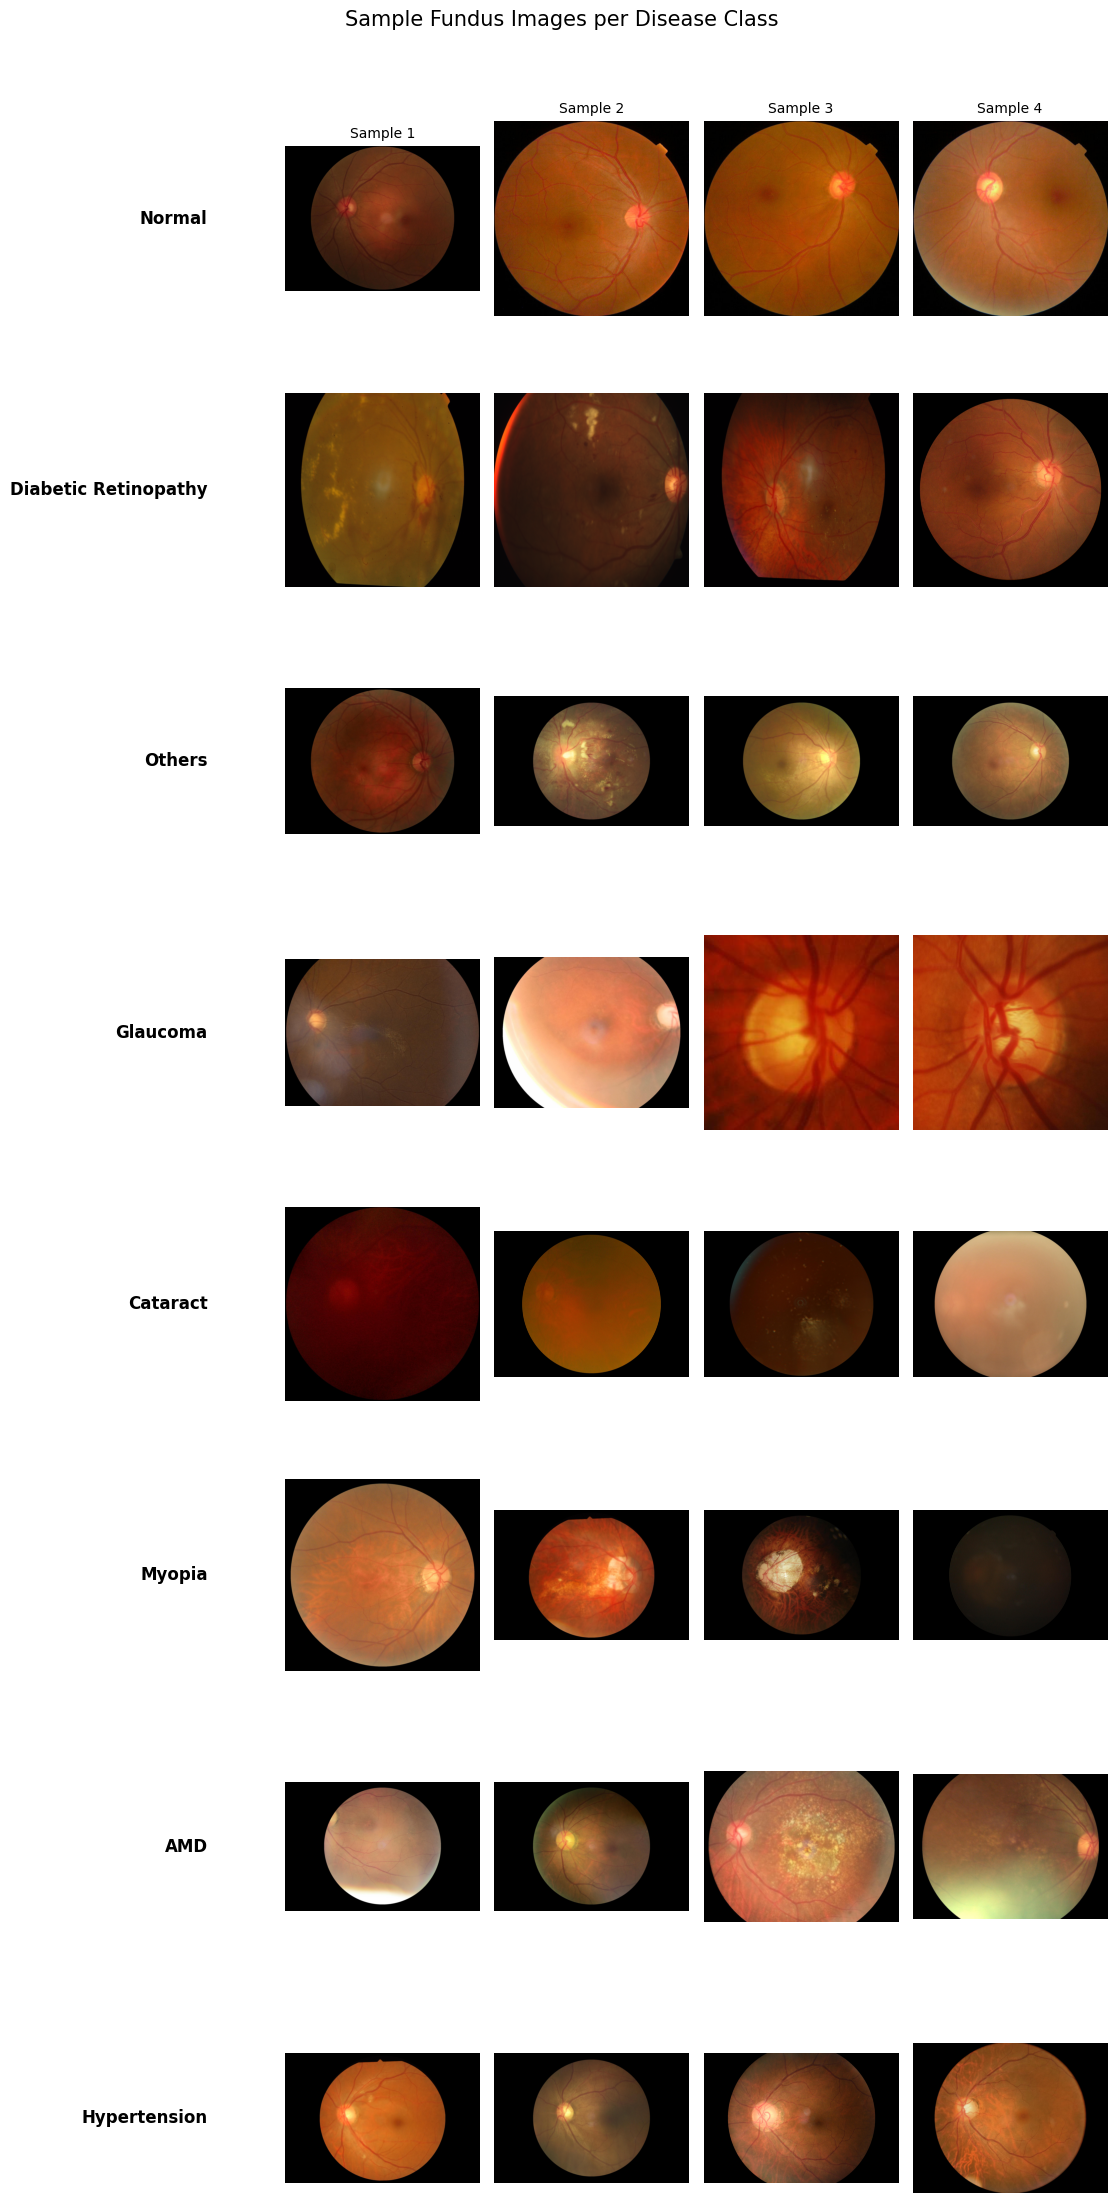

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import pandas as pd

meta = pd.read_csv("/content/dataset/metadata.csv")
img_dir = "/content/dataset/images"

classes = meta['unified_label'].value_counts().index.tolist()  # ordered by count, descending
n_samples = 4  # images per class

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.8, len(classes) * 2.8))

for row, cls in enumerate(classes):
    cls_files = meta[meta['unified_label'] == cls]['filename'].sample(
        n_samples, random_state=42, replace=False
    ).tolist()

    for col, fname in enumerate(cls_files):
        img_path = os.path.join(img_dir, fname)
        img = Image.open(img_path).convert("RGB")
        ax = axes[row, col]
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, rotation=0, labelpad=60, va='center')
        if row == 0:
            ax.set_title(f"Sample {col+1}", fontsize=10)

    # Add class label as row title on the left
    axes[row, 0].text(
        -0.4, 0.5, cls, fontsize=12, fontweight='bold',
        va='center', ha='right', transform=axes[row, 0].transAxes
    )

plt.suptitle("Sample Fundus Images per Disease Class", fontsize=15, y=1.005)
plt.tight_layout()
plt.savefig("/content/sample_images_per_class.png", dpi=150, bbox_inches='tight')
plt.show()